In [1]:
from datasets import load_dataset

clinc = load_dataset("DeepPavlov/clinc150")

print(clinc)

DatasetDict({
    train: Dataset({
        features: ['utterance', 'label'],
        num_rows: 15200
    })
    validation: Dataset({
        features: ['utterance', 'label'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['utterance', 'label'],
        num_rows: 5500
    })
})


In [2]:
print(clinc["train"].info)

DatasetInfo(features={'utterance': Value('string'), 'label': Value('int64')}, builder_name='parquet', dataset_name='clinc150', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=857605, num_examples=15200, dataset_name='clinc150'), 'validation': SplitInfo(name='validation', num_bytes=160686, num_examples=3100, dataset_name='clinc150'), 'test': SplitInfo(name='test', num_bytes=287654, num_examples=5500, dataset_name='clinc150')}, download_size=542584, dataset_size=1305945, size_in_bytes=1848529)


In [3]:
print(clinc["train"].features)

{'utterance': Value('string'), 'label': Value('int64')}


In [4]:
print(clinc["train"].features["label"])

Value('int64')


In [5]:
hwu = load_dataset("DeepPavlov/hwu64")

print(hwu["train"].features["label"])

Value('int64')


In [6]:
import os

print(os.getcwd())

/Users/varad/Downloads/FAQ_Genie/FAQ_Genie/ML/notebooks


In [7]:
import os

print(os.listdir(".."))

['requirements.txt', 'clinc150_train_cleaned.csv', 'clinc150_validation_cleaned.csv', 'clinc150_test_cleaned.csv', 'download.py', 'clinc150_intent_mapping.csv', 'hwu64_domain_mapping.json', 'venv', 'hwu64_train_cleaned.csv', 'notebooks', 'hwu64_test_cleaned.csv', 'hwu64_intent_mapping.csv', 'clinc150_domain_mapping.json']


In [8]:
print(os.listdir("../.."))

['ML', 'requirement.txt', '.git']


In [9]:
from datasets import load_dataset

clinc_intents = load_dataset(
    "DeepPavlov/clinc150",
    "intents"
)

print(clinc_intents)

DatasetDict({
    intents: Dataset({
        features: ['id', 'name', 'tags', 'regexp_full_match', 'regexp_partial_match', 'description'],
        num_rows: 150
    })
})


In [10]:
print(clinc_intents["intents"].features)

{'id': Value('int64'), 'name': Value('string'), 'tags': List(Value('null')), 'regexp_full_match': List(Value('null')), 'regexp_partial_match': List(Value('null')), 'description': Value('null')}


In [11]:
for row in clinc_intents["intents"]:
    print(row)

{'id': 0, 'name': 'accept_reservations', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 1, 'name': 'account_blocked', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 2, 'name': 'alarm', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 3, 'name': 'application_status', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 4, 'name': 'apr', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 5, 'name': 'are_you_a_bot', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 6, 'name': 'balance', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 7, 'name': 'bill_balance', 'tags': [], 'regexp_full_match': [], 'regexp_partial_match': [], 'description': None}
{'id': 8, 'name': 'bill_due', 'tags': [], 'r

In [12]:
import pandas as pd

intent_df = pd.DataFrame(clinc_intents["intents"])

print(intent_df[["id", "name"]].to_string(index=False))

 id                      name
  0       accept_reservations
  1           account_blocked
  2                     alarm
  3        application_status
  4                       apr
  5             are_you_a_bot
  6                   balance
  7              bill_balance
  8                  bill_due
  9               book_flight
 10                book_hotel
 11                calculator
 12                  calendar
 13           calendar_update
 14                  calories
 15                    cancel
 16        cancel_reservation
 17                car_rental
 18             card_declined
 19                  carry_on
 20             change_accent
 21            change_ai_name
 22           change_language
 23              change_speed
 24          change_user_name
 25             change_volume
 26       confirm_reservation
 27                 cook_time
 28              credit_limit
 29       credit_limit_change
 30              credit_score
 31          current_location
 32       

In [13]:
intent_df[["id", "name"]].to_csv(
    "../clinc150_intent_mapping.csv",
    index=False
)

In [14]:
train_df = clinc["train"].to_pandas()

train_df = train_df.merge(
    intent_df[["id", "name"]],
    left_on="label",
    right_on="id",
    how="left"
)

train_df = train_df.rename(columns={
    "name": "intent"
})

print(train_df[["utterance", "label", "intent"]].head(20))

                                            utterance  label  \
0               can i make a reservation for redrobin    0.0   
1    is it possible to make a reservation at redrobin    0.0   
2                     does redrobin take reservations    0.0   
3                  are reservations taken at redrobin    0.0   
4                       does redrobin do reservations    0.0   
5                          can acero take reservation    0.0   
6                can you make reservations at hodak's    0.0   
7         tell me if per se in nyc takes reservations    0.0   
8          tell me if the cheshire takes reservations    0.0   
9                        will qdoba take reservations    0.0   
10               does burger king accept reservations    0.0   
11  does gramercy tavern in new york accept reserv...    0.0   
12         does acero in maplewood allow reservations    0.0   
13                       does cielo take reservations    0.0   
14  find out if la tour d'argent in pari

In [15]:
intent_df[["id", "name"]].head(30)

,id,name
0,0,accept_reservations
1,1,account_blocked
2,2,alarm
3,3,application_status
4,4,apr
5,5,are_you_a_bot
6,6,balance
7,7,bill_balance
8,8,bill_due
9,9,book_flight


In [16]:
for _, row in intent_df.iterrows():
    print(f"{row['id']:3} : {row['name']}")

  0 : accept_reservations
  1 : account_blocked
  2 : alarm
  3 : application_status
  4 : apr
  5 : are_you_a_bot
  6 : balance
  7 : bill_balance
  8 : bill_due
  9 : book_flight
 10 : book_hotel
 11 : calculator
 12 : calendar
 13 : calendar_update
 14 : calories
 15 : cancel
 16 : cancel_reservation
 17 : car_rental
 18 : card_declined
 19 : carry_on
 20 : change_accent
 21 : change_ai_name
 22 : change_language
 23 : change_speed
 24 : change_user_name
 25 : change_volume
 26 : confirm_reservation
 27 : cook_time
 28 : credit_limit
 29 : credit_limit_change
 30 : credit_score
 31 : current_location
 32 : damaged_card
 33 : date
 34 : definition
 35 : direct_deposit
 36 : directions
 37 : distance
 38 : do_you_have_pets
 39 : exchange_rate
 40 : expiration_date
 41 : find_phone
 42 : flight_status
 43 : flip_coin
 44 : food_last
 45 : freeze_account
 46 : fun_fact
 47 : gas
 48 : gas_type
 49 : goodbye
 50 : greeting
 51 : how_busy
 52 : how_old_are_you
 53 : improve_credit_score
 

In [17]:
clinc_domain_map = {
    "Finance & Banking": [
        "account_blocked",
        "application_status",
        "apr",
        "balance",
        "bill_balance",
        "bill_due",
        "card_declined",
        "credit_limit",
        "credit_limit_change",
        "credit_score",
        "damaged_card",
        "direct_deposit",
        "expiration_date",
        "freeze_account",
        "improve_credit_score",
        "income",
        "interest_rate",
        "international_fees",
        "min_payment",
        "new_card",
        "order_checks",
        "pay_bill",
        "payday",
        "pin_change",
        "redeem_rewards",
        "replacement_card_duration",
        "report_fraud",
        "report_lost_card",
        "rewards_balance",
        "rollover_401k",
        "routing",
        "spending_history",
        "taxes",
        "transactions",
        "transfer",
        "w2",
    ],

    "Travel, Transportation & Navigation": [
        "accept_reservations",
        "book_flight",
        "book_hotel",
        "car_rental",
        "carry_on",
        "confirm_reservation",
        "directions",
        "distance",
        "flight_status",
        "international_visa",
        "lost_luggage",
        "share_location",
        "current_location",
        "restaurant_reservation",
        "cancel_reservation",
        "travel_alert",
        "travel_notification",
        "travel_suggestion",
        "uber",
        "traffic",
    ],

    "Automotive": [
        "gas",
        "gas_type",
        "jump_start",
        "last_maintenance",
        "mpg",
        "oil_change_how",
        "oil_change_when",
        "schedule_maintenance",
        "tire_change",
        "tire_pressure",
    ],

    "Food & Cooking": [
        "calories",
        "cook_time",
        "food_last",
        "ingredient_substitution",
        "ingredients_list",
        "meal_suggestion",
        "nutrition_info",
        "recipe",
    ],

    "Productivity & Personal Organization": [
        "alarm",
        "calendar",
        "timer",
        "calendar_update",
        "meeting_schedule",
        "schedule_meeting",
        "reminder",
        "reminder_update",
        "pto_balance",
        "pto_request",
        "pto_request_status",
        "pto_used",
        "todo_list",
        "todo_list_update",
        "shopping_list",
        "shopping_list_update",
    ],

    "Shopping & Orders": [
        "order",
        "order_status",
    ],

    "Smart Home & Devices": [
        "find_phone",
        "smart_home",
        "sync_device",
        "plug_type",
    ],

    "Music & Media": [
        "next_song",
        "play_music",
        "update_playlist",
        "what_song",
    ],

    "Communication": [
        "make_call",
        "text",
    ],

    "Health & Insurance": [
        "insurance",
        "insurance_change",
        "vaccines",
    ],

    "General Knowledge & Utilities": [
        "calculator",
        "date",
        "definition",
        "exchange_rate",
        "measurement_conversion",
        "spelling",
        "time",
        "flip_coin",
        "roll_dice",
        "translate",
        "timezone",
        "next_holiday",
        "fun_fact",
    ],

    "Weather & Environment": [
        "weather",
    ],

    "Assistant & Conversational": [
        "are_you_a_bot",
        "change_accent",
        "change_ai_name",
        "change_language",
        "change_speed",
        "change_user_name",
        "change_volume",
        "do_you_have_pets",
        "goodbye",
        "greeting",
        "how_old_are_you",
        "maybe",
        "meaning_of_life",
        "reset_settings",
        "repeat",
        "tell_joke",
        "thank_you",
        "user_name",
        "what_are_your_hobbies",
        "what_can_i_ask_you",
        "what_is_your_name",
        "where_are_you_from",
        "whisper_mode",
        "who_do_you_work_for",
        "who_made_you",
        "yes",
        "no",
        "cancel",
    ],
        "Food & Dining": [
        "restaurant_suggestion",
        "restaurant_reviews",
    ],
        "Availability / Services": [
        "how_busy",
    ],
}

In [18]:
intent_to_domain = {
    intent: domain
    for domain, intents in clinc_domain_map.items()
    for intent in intents
}

In [19]:
print(intent_to_domain["credit_score"])
print(intent_to_domain["recipe"])
print(intent_to_domain["oil_change_how"])

Finance & Banking
Food & Cooking
Automotive


In [20]:
all_intents = set(intent_df["name"])

mapped_intents = set(intent_to_domain.keys())

print("Total CLINC intents:", len(all_intents))
print("Mapped intents:", len(mapped_intents))

missing = all_intents - mapped_intents
extra = mapped_intents - all_intents

print("\nMissing intents:")
print(missing)

print("\nInvalid/extra intents:")
print(extra)

Total CLINC intents: 150
Mapped intents: 150

Missing intents:
set()

Invalid/extra intents:
set()


In [21]:
train_df["domain"] = train_df["intent"].map(intent_to_domain)

In [22]:
print(train_df[["utterance", "intent", "domain"]].head(20))

                                            utterance               intent  \
0               can i make a reservation for redrobin  accept_reservations   
1    is it possible to make a reservation at redrobin  accept_reservations   
2                     does redrobin take reservations  accept_reservations   
3                  are reservations taken at redrobin  accept_reservations   
4                       does redrobin do reservations  accept_reservations   
5                          can acero take reservation  accept_reservations   
6                can you make reservations at hodak's  accept_reservations   
7         tell me if per se in nyc takes reservations  accept_reservations   
8          tell me if the cheshire takes reservations  accept_reservations   
9                        will qdoba take reservations  accept_reservations   
10               does burger king accept reservations  accept_reservations   
11  does gramercy tavern in new york accept reserv...  accept_re

In [23]:
domain_counts = train_df["domain"].value_counts()

print(domain_counts)

domain
Finance & Banking                       3600
Assistant & Conversational              2800
Travel, Transportation & Navigation     2000
Productivity & Personal Organization    1600
General Knowledge & Utilities           1300
Automotive                              1000
Food & Cooking                           800
Smart Home & Devices                     400
Music & Media                            400
Health & Insurance                       300
Communication                            200
Shopping & Orders                        200
Food & Dining                            200
Availability / Services                  100
Weather & Environment                    100
Name: count, dtype: int64


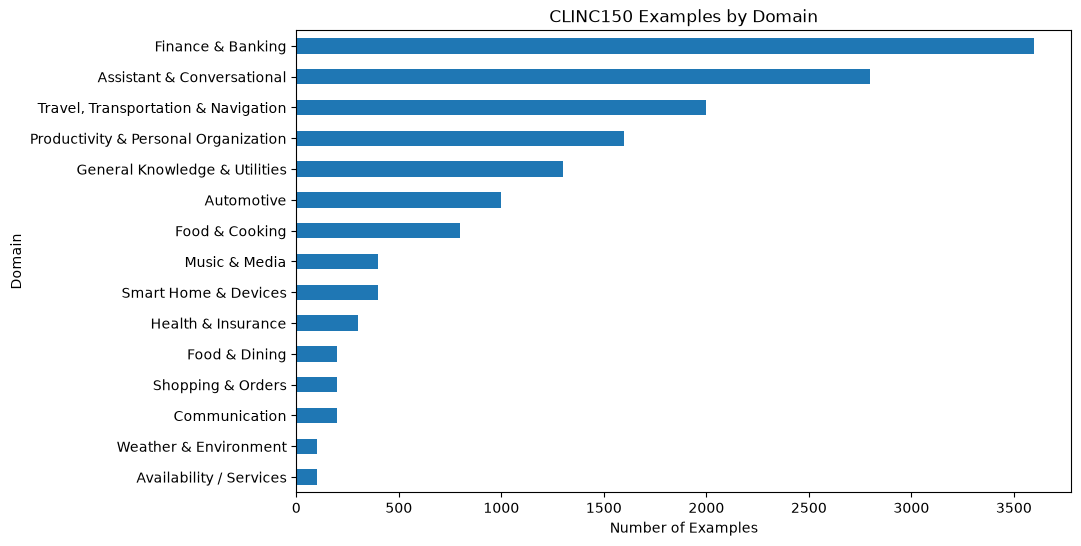

In [24]:
import matplotlib.pyplot as plt

domain_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("CLINC150 Examples by Domain")
plt.xlabel("Number of Examples")
plt.ylabel("Domain")
plt.show()

In [25]:
from datasets import load_dataset

hwu = load_dataset("DeepPavlov/hwu64")

print(hwu)

DatasetDict({
    train: Dataset({
        features: ['utterance', 'label'],
        num_rows: 8954
    })
    test: Dataset({
        features: ['utterance', 'label'],
        num_rows: 1076
    })
})


In [26]:
hwu_intents = load_dataset(
    "DeepPavlov/hwu64",
    "intents"
)

print(hwu_intents)

DatasetDict({
    intents: Dataset({
        features: ['id', 'name', 'tags', 'regexp_full_match', 'regexp_partial_match', 'description'],
        num_rows: 64
    })
})


In [27]:
hwu_intent_df = hwu_intents["intents"].to_pandas()

print(hwu_intent_df[["id", "name"]].to_string(index=False))

 id                     name
  0              alarm_query
  1             alarm_remove
  2                alarm_set
  3        audio_volume_down
  4        audio_volume_mute
  5          audio_volume_up
  6           calendar_query
  7          calendar_remove
  8             calendar_set
  9           cooking_recipe
 10         datetime_convert
 11           datetime_query
 12         email_addcontact
 13              email_query
 14       email_querycontact
 15          email_sendemail
 16           general_affirm
 17      general_commandstop
 18          general_confirm
 19         general_dontcare
 20          general_explain
 21             general_joke
 22           general_negate
 23           general_praise
 24           general_quirky
 25           general_repeat
 26             iot_cleaning
 27               iot_coffee
 28      iot_hue_lightchange
 29         iot_hue_lightdim
 30         iot_hue_lightoff
 31          iot_hue_lighton
 32          iot_hue_lightup
 33           

In [28]:
hwu_train_df = hwu["train"].to_pandas()

hwu_train_df = hwu_train_df.merge(
    hwu_intent_df[["id", "name"]],
    left_on="label",
    right_on="id",
    how="left"
)

hwu_train_df = hwu_train_df.rename(
    columns={"name": "intent"}
)

print(hwu_train_df[["utterance", "label", "intent"]].head(20))

                                            utterance  label       intent
0                 what alarms do i have set right now      0  alarm_query
1                     checkout today alarm of meeting      0  alarm_query
2                               report alarm settings      0  alarm_query
3   see see for me the alarms that you have set to...      0  alarm_query
4                        is there an alarm for ten am      0  alarm_query
5                              confirm the alarm time      0  alarm_query
6                                      show my alarms      0  alarm_query
7              at what time have you set alarm for me      0  alarm_query
8                           please list active alarms      0  alarm_query
9                please tell me about upcoming alarms      0  alarm_query
10                what alarms have i set for tomorrow      0  alarm_query
11                     have i set any alarm for today      0  alarm_query
12                        what alarms 

In [29]:
for _, row in hwu_intent_df.iterrows():
    print(f"{row['id']:2} : {row['name']}")

 0 : alarm_query
 1 : alarm_remove
 2 : alarm_set
 3 : audio_volume_down
 4 : audio_volume_mute
 5 : audio_volume_up
 6 : calendar_query
 7 : calendar_remove
 8 : calendar_set
 9 : cooking_recipe
10 : datetime_convert
11 : datetime_query
12 : email_addcontact
13 : email_query
14 : email_querycontact
15 : email_sendemail
16 : general_affirm
17 : general_commandstop
18 : general_confirm
19 : general_dontcare
20 : general_explain
21 : general_joke
22 : general_negate
23 : general_praise
24 : general_quirky
25 : general_repeat
26 : iot_cleaning
27 : iot_coffee
28 : iot_hue_lightchange
29 : iot_hue_lightdim
30 : iot_hue_lightoff
31 : iot_hue_lighton
32 : iot_hue_lightup
33 : iot_wemo_off
34 : iot_wemo_on
35 : lists_createoradd
36 : lists_query
37 : lists_remove
38 : music_likeness
39 : music_query
40 : music_settings
41 : news_query
42 : play_audiobook
43 : play_game
44 : play_music
45 : play_podcasts
46 : play_radio
47 : qa_currency
48 : qa_definition
49 : qa_factoid
50 : qa_maths
51 : qa_

In [30]:
hwu_domain_map = {
    "Productivity & Personal Organization": [
        "alarm_query",
        "alarm_remove",
        "alarm_set",
        "calendar_query",
        "calendar_remove",
        "calendar_set",
        "datetime_convert",
        "datetime_query",
        "lists_createoradd",
        "lists_query",
        "lists_remove",
    ],

    "Smart Home & IoT": [
        "audio_volume_down",
        "audio_volume_mute",
        "audio_volume_up",
        "iot_cleaning",
        "iot_coffee",
        "iot_hue_lightchange",
        "iot_hue_lightdim",
        "iot_hue_lightoff",
        "iot_hue_lighton",
        "iot_hue_lightup",
        "iot_wemo_off",
        "iot_wemo_on",
    ],

    "Communication": [
        "email_addcontact",
        "email_query",
        "email_querycontact",
        "email_sendemail",
    ],

    "Conversational & General Assistant": [
        "general_affirm",
        "general_commandstop",
        "general_confirm",
        "general_dontcare",
        "general_explain",
        "general_joke",
        "general_negate",
        "general_praise",
        "general_quirky",
        "general_repeat",
    ],

    "Food & Cooking": [
        "cooking_recipe",
    ],

    "Music & Media": [
        "music_likeness",
        "music_query",
        "music_settings",
        "play_audiobook",
        "play_game",
        "play_music",
        "play_podcasts",
        "play_radio",
    ],

    "General Knowledge & Utilities": [
        "qa_currency",
        "qa_definition",
        "qa_factoid",
        "qa_maths",
        "qa_stock",
    ],

    "Recommendations & Discovery": [
        "recommendation_events",
        "recommendation_locations",
        "recommendation_movies",
    ],

    "Social Media": [
        "social_post",
        "social_query",
    ],

    "Food & Dining": [
        "takeaway_order",
        "takeaway_query",
    ],

    "Travel & Transportation": [
        "transport_query",
        "transport_taxi",
        "transport_ticket",
        "transport_traffic",
    ],

    "Weather": [
        "weather_query",
    ],
    "News & Current Information": [
        "news_query",
    ],
}

In [31]:
all_hwu_intents = set(hwu_intent_df["name"])
mapped_hwu_intents = set(
    intent
    for intents in hwu_domain_map.values()
    for intent in intents
)

print("Total HWU64 intents:", len(all_hwu_intents))
print("Mapped intents:", len(mapped_hwu_intents))

print("\nMissing:")
print(all_hwu_intents - mapped_hwu_intents)

print("\nExtra:")
print(mapped_hwu_intents - all_hwu_intents)

Total HWU64 intents: 64
Mapped intents: 64

Missing:
set()

Extra:
set()


In [32]:
hwu_intent_to_domain = {
    intent: domain
    for domain, intents in hwu_domain_map.items()
    for intent in intents
}

hwu_train_df["domain"] = hwu_train_df["intent"].map(hwu_intent_to_domain)

In [33]:
hwu_domain_counts = hwu_train_df["domain"].value_counts()

print(hwu_domain_counts)

domain
Productivity & Personal Organization    1584
Conversational & General Assistant      1510
Smart Home & IoT                        1305
Music & Media                           1150
General Knowledge & Utilities            752
Travel & Transportation                  614
Communication                            541
Recommendations & Discovery              404
Food & Dining                            313
Social Media                             309
News & Current Information               158
Food & Cooking                           157
Weather                                  157
Name: count, dtype: int64


In [34]:
hwu_intent_df[["id", "name"]].to_csv(
    "../hwu64_intent_mapping.csv",
    index=False
)

In [35]:
import json

with open("../hwu64_domain_mapping.json", "w") as f:
    json.dump(hwu_domain_map, f, indent=4)

In [36]:
with open("../clinc150_domain_mapping.json", "w") as f:
    json.dump(clinc_domain_map, f, indent=4)

In [37]:
import pandas as pd

clinc_clean = pd.read_csv("../clinc150_train_cleaned.csv")
hwu_clean = pd.read_csv("../hwu64_train_cleaned.csv")

clinc_intents_clean = sorted(clinc_clean["intent"].unique())
hwu_intents_clean = sorted(hwu_clean["intent"].unique())

print("CLINC cleaned intents:", len(clinc_intents_clean))
print("HWU cleaned intents:", len(hwu_intents_clean))

CLINC cleaned intents: 125
HWU cleaned intents: 56


In [38]:
exact_overlap = set(clinc_intents_clean) & set(hwu_intents_clean)

print("Exact overlapping intents:")
for intent in sorted(exact_overlap):
    print(intent)

print("\nNumber of exact overlaps:", len(exact_overlap))

Exact overlapping intents:
play_music

Number of exact overlaps: 1


In [39]:
semantic_candidates = {
    "music_playback": {
        "clinc": ["play_music", "next_song", "what_song"],
        "hwu": ["play_music", "music_query"]
    },

    "recipe_request": {
        "clinc": ["recipe"],
        "hwu": ["cooking_recipe"]
    },

    "currency_information": {
        "clinc": ["exchange_rate"],
        "hwu": ["qa_currency"]
    },

    "definition_request": {
        "clinc": ["definition"],
        "hwu": ["qa_definition"]
    },

    "math_calculation": {
        "clinc": ["calculator"],
        "hwu": ["qa_maths"]
    },

    "weather_information": {
        "clinc": ["weather"],
        "hwu": ["weather_query"]
    },

    "traffic_information": {
        "clinc": ["traffic"],
        "hwu": ["transport_traffic"]
    },

    "volume_control": {
        "clinc": ["change_volume"],
        "hwu": ["audio_volume_down", "audio_volume_mute", "audio_volume_up"]
    },

    "calendar": {
        "clinc": ["calendar", "calendar_update"],
        "hwu": ["calendar_query", "calendar_set", "calendar_remove"]
    },

    "alarm": {
        "clinc": ["alarm"],
        "hwu": ["alarm_query", "alarm_set", "alarm_remove"]
    },

    "food_ordering": {
        "clinc": ["order"],
        "hwu": ["takeaway_order", "takeaway_query"]
    },

    "transportation": {
        "clinc": ["uber"],
        "hwu": ["transport_taxi"]
    },

    "device_control": {
        "clinc": ["smart_home"],
        "hwu": [
            "iot_cleaning",
            "iot_coffee",
            "iot_hue_lightchange",
            "iot_hue_lightdim",
            "iot_hue_lightoff",
            "iot_hue_lighton",
            "iot_hue_lightup",
            "iot_wemo_off",
            "iot_wemo_on"
        ]
    }
}

for canonical, mapping in semantic_candidates.items():
    print(f"\n{canonical}")
    print("  CLINC:", mapping["clinc"])
    print("  HWU:  ", mapping["hwu"])


music_playback
  CLINC: ['play_music', 'next_song', 'what_song']
  HWU:   ['play_music', 'music_query']

recipe_request
  CLINC: ['recipe']
  HWU:   ['cooking_recipe']

currency_information
  CLINC: ['exchange_rate']
  HWU:   ['qa_currency']

definition_request
  CLINC: ['definition']
  HWU:   ['qa_definition']

math_calculation
  CLINC: ['calculator']
  HWU:   ['qa_maths']

weather_information
  CLINC: ['weather']
  HWU:   ['weather_query']

traffic_information
  CLINC: ['traffic']
  HWU:   ['transport_traffic']

volume_control
  CLINC: ['change_volume']
  HWU:   ['audio_volume_down', 'audio_volume_mute', 'audio_volume_up']

calendar
  CLINC: ['calendar', 'calendar_update']
  HWU:   ['calendar_query', 'calendar_set', 'calendar_remove']

alarm
  CLINC: ['alarm']
  HWU:   ['alarm_query', 'alarm_set', 'alarm_remove']

food_ordering
  CLINC: ['order']
  HWU:   ['takeaway_order', 'takeaway_query']

transportation
  CLINC: ['uber']
  HWU:   ['transport_taxi']

device_control
  CLINC: ['sma

In [ ]:
CANONICAL_MAP = {
    "recipe": "recipe_request",
    "cooking_recipe": "recipe_request",

    "exchange_rate": "currency_information",
    "qa_currency": "currency_information",

    "definition": "definition_information",
    "qa_definition": "definition_information",

    "calculator": "math_calculation",
    "qa_maths": "math_calculation",

    "weather": "weather_information",
    "weather_query": "weather_information",

    "traffic": "traffic_information",
    "transport_traffic": "traffic_information",

    "calendar": "calendar_information",
    "calendar_query": "calendar_information",

    "alarm": "alarm_set",
    "alarm_set": "alarm_set",
}

Canonical mappings: 13


In [41]:
for old_intent, canonical_intent in CANONICAL_MAP.items():
    print(f"{old_intent:25} -> {canonical_intent}")

play_music                -> play_music
recipe                    -> recipe_request
cooking_recipe            -> recipe_request
exchange_rate             -> currency_information
qa_currency               -> currency_information
definition                -> definition_request
qa_definition             -> definition_request
calculator                -> math_calculation
qa_maths                  -> math_calculation
weather                   -> weather_information
weather_query             -> weather_information
traffic                   -> traffic_information
transport_traffic         -> traffic_information


In [42]:
def show_examples(df, intent, n=5):
    print(f"\n===== {intent} =====")

    examples = df.loc[
        df["intent"] == intent,
        "utterance"
    ].head(n)

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")

In [43]:
show_examples(clinc_clean, "what_song")
show_examples(hwu_clean, "music_query")


===== what_song =====
1. which song is playing
2. what's this song called
3. what song is this
4. what's the name of this song
5. what is this song

===== music_query =====
1. show me music by that artist
2. name the singer
3. what's the song title
4. which song is currently playing
5. what is the name of the artist that created this song


In [44]:
show_examples(clinc_clean, "restaurant_suggestion")
show_examples(hwu_clean, "recommendation_locations")


===== restaurant_suggestion =====
1. can you suggest a restaurant for me to eat tonight
2. tell me where to go since i want to eat out tonight
3. i'm craving for italian food, where should i go
4. suggest a restaurant for me to eat tonight, please
5. i'm not going to cook today, can you suggest a restaurant

===== recommendation_locations =====
1. whats the best place to eat near here
2. whats around
3. show shops around second street
4. what's the best chicken place near me
5. where is the best pizza on sixth street


In [45]:
show_examples(clinc_clean, "order")
show_examples(hwu_clean, "takeaway_order")
show_examples(hwu_clean, "takeaway_query")


===== order =====
1. can you please order me more plastic bags
2. i need you to order some more lysol for me,please
3. i need some more lysol, could you order me some
4. i'm out of lysol could you order me some
5. could you please reorder me some lysol

===== takeaway_order =====
1. order me some chipotle
2. could you please help me to order some sushi from deliveroo
3. order chinese food
4. show me chinese food near me
5. ordering food

===== takeaway_query =====
1. call pizza hut and find out if my order is ready
2. find a pizza restaurant open until noon
3. does my favourite pizza place available for takeaway
4. does pf changs do takeout
5. find my thai takeaways around grassmarket


In [46]:
show_examples(clinc_clean, "smart_home")
show_examples(hwu_clean, "iot_coffee")
show_examples(hwu_clean, "iot_hue_lighton")


===== smart_home =====
1. can you please turn on my furnace
2. oven should be set to 350 now
3. what temp is the ac at
4. tell me who is by the garage door
5. set my oven to 350 please

===== iot_coffee =====
1. please activate my coffee pot for me
2. i need a drink
3. make us a brew
4. please make me a coffee using the coffee machine
5. please get the coffee machine to make me some coffee

===== iot_hue_lighton =====
1. hey turn on disco lights in my apartment and let the party begin
2. overhead lights on please
3. please turn the lights on
4. turn on the lights that are outdoors
5. i can't see anything


In [47]:
show_examples(clinc_clean, "shopping_list")
show_examples(hwu_clean, "lists_query")

show_examples(clinc_clean, "shopping_list_update")
show_examples(hwu_clean, "lists_createoradd")
show_examples(hwu_clean, "lists_remove")


===== shopping_list =====
1. would you let me know what is on my shopping list
2. list out what is on my shopping list
3. i need for you to tell me what is on my shopping list
4. do you want me to shop for peanut butter
5. do you want peanut butter for your lunches this week

===== lists_query =====
1. i finished my to do list
2. list the items on my shopping list
3. what are all my lists
4. display my list
5. what kind of lists do i have saved

===== shopping_list_update =====
1. delete fries from shopping list
2. take off fries from the shopping list
3. please take away the fries from the shopping list
4. remove fries from my shopping list
5. we no longer need fries on the shopping lisr

===== lists_createoradd =====
1. add a tab to the shopping list
2. show a new list
3. add grocery shopping to my to do list
4. update my list with shoes
5. include this

===== lists_remove =====
1. delete the dog list for me
2. delete item on list
3. please delete list titled kickball
4. remove this

In [48]:
show_examples(clinc_clean, "date")
show_examples(hwu_clean, "datetime_query")
show_examples(hwu_clean, "datetime_convert")

show_examples(clinc_clean, "time")
show_examples(hwu_clean, "datetime_query")

show_examples(clinc_clean, "current_location")
show_examples(hwu_clean, "transport_query")

show_examples(clinc_clean, "directions")
show_examples(hwu_clean, "transport_query")


===== date =====
1. i would like to know what today's date is
2. i need information on today's date
3. tell me what date it is please
4. tell me what day today is
5. can you tell me tomorrow's date

===== datetime_query =====
1. give me time
2. could you please tell me what time is in singapore
3. report the current time in oakland
4. the twenty second is on what day of the week
5. what week of the year does the summer season start

===== datetime_convert =====
1. if it is noon in virginia what time is it in california
2. switch to eastern time zone
3. please change time zone to india
4. change this time to ist
5. please convert the time of here at nine pm to brasil time zone

===== time =====
1. what time is it in punta gorda, florida
2. what time is it in glenwood springs, co
3. what time is it in fredericksburg, tx
4. what time is it in las vegas, nv
5. what time is it in houston, tx

===== datetime_query =====
1. give me time
2. could you please tell me what time is in singapore
3

In [49]:
show_examples(clinc_clean, "meal_suggestion")
show_examples(hwu_clean, "recommendation_locations")

show_examples(clinc_clean, "travel_suggestion")
show_examples(hwu_clean, "recommendation_locations")

show_examples(clinc_clean, "restaurant_reviews")
show_examples(hwu_clean, "recommendation_locations")

show_examples(clinc_clean, "make_call")
show_examples(hwu_clean, "email_sendemail")

show_examples(clinc_clean, "text")
show_examples(hwu_clean, "social_post")


===== meal_suggestion =====
1. can you give me a french dinner suggestion
2. suggest a meal from laos to me, please
3. can you give me a vietnamese meal suggestion
4. suggest a meal from burma to me
5. can you give me a vietnamese dinner suggestion

===== recommendation_locations =====
1. whats the best place to eat near here
2. whats around
3. show shops around second street
4. what's the best chicken place near me
5. where is the best pizza on sixth street

===== travel_suggestion =====
1. can you give me some suggestions to go site seeing when i get there
2. can you get me any recommendations for the place i'm traveling to
3. please suggest some fun tourist activities in tokyo
4. i need help with some fun tourist things to do in tokyo
5. could you tell me what fun tourist things i could do in tokyo

===== recommendation_locations =====
1. whats the best place to eat near here
2. whats around
3. show shops around second street
4. what's the best chicken place near me
5. where is the

In [50]:
show_examples(clinc_clean, "restaurant_reservation")
show_examples(hwu_clean, "recommendation_events")

show_examples(clinc_clean, "restaurant_reservation")
show_examples(hwu_clean, "takeaway_query")

show_examples(clinc_clean, "travel_suggestion")
show_examples(hwu_clean, "recommendation_events")

show_examples(clinc_clean, "next_song")
show_examples(hwu_clean, "music_query")

show_examples(clinc_clean, "what_song")
show_examples(hwu_clean, "music_query")


===== restaurant_reservation =====
1. you need to call the melt in lakewood for a table for at 2:00, monday, the first week in march
2. hey computer, make a reservation for 2 for my parents at red lobster on wednseday next, 2:00pm if possible
3. i think we should reserve dad's regular table friday for 6 people, use his name, make that close to 4:00 pm at the club
4. listen i need to get a reservation for , me and teresa at georgetown cafe on tuesday at 7:00 pm
5. can you make me a reservation for 4 pm on the 22nd at ruth's

===== recommendation_events =====
1. show me all the events happening in milan
2. what are some local events
3. can you tell me some fun things to do in kentucky
4. is there anything to do tonight
5. what is happening in the area

===== restaurant_reservation =====
1. you need to call the melt in lakewood for a table for at 2:00, monday, the first week in march
2. hey computer, make a reservation for 2 for my parents at red lobster on wednseday next, 2:00pm if poss

In [51]:
show_examples(clinc_clean, "account_blocked")
show_examples(clinc_clean, "freeze_account")
show_examples(hwu_clean, "general_explain")   # only to see whether it is actually useful; don't merge yet

show_examples(clinc_clean, "order_status")
show_examples(hwu_clean, "takeaway_query")

show_examples(clinc_clean, "find_phone")
show_examples(hwu_clean, "transport_query")   # just checking broader behavior


===== account_blocked =====
1. why is there a hold on my american saving bank account
2. i am nost sure why my account is blocked
3. why is there a hold on my capital one checking account
4. i think my account is blocked but i do not know the reason
5. can you tell me why is my bank account frozen

===== freeze_account =====
1. can you block my chase account right away please
2. i want my chase account blocked immediately
3. i need you to block my chase account immediately
4. can you put a block on my chase account right away
5. please block my chase account right away

===== general_explain =====
1. once again clarify me about your answers please.
2. don't get this.
3. explain it further please.
4. s1, rephrase me more on it.
5. would you once again clarify me about your response please.

===== order_status =====
1. can you find my package in transit
2. track my package please
3. help me find my package
4. i need to track my package
5. what's going on with my order

===== takeaway_qu

In [52]:
show_examples(clinc_clean, "order_status")
show_examples(hwu_clean, "takeaway_query")

show_examples(clinc_clean, "find_phone")
show_examples(hwu_clean, "iot_cleaning")

show_examples(clinc_clean, "sync_device")
show_examples(hwu_clean, "general_explain")


===== order_status =====
1. can you find my package in transit
2. track my package please
3. help me find my package
4. i need to track my package
5. what's going on with my order

===== takeaway_query =====
1. call pizza hut and find out if my order is ready
2. find a pizza restaurant open until noon
3. does my favourite pizza place available for takeaway
4. does pf changs do takeout
5. find my thai takeaways around grassmarket

===== find_phone =====
1. i need help finding my mobile phone
2. help me figure out where my cell phone is
3. give me a hand finding my mobile device
4. i can't find my cell and need help locating it
5. can you help me find my cell

===== iot_cleaning =====
1. by ten to eleven am daily start my vacuum cleaner
2. please clean the floor
3. start roomba
4. i want to turn on the robot vacuum cleaner
5. activate robot vacuum

===== sync_device =====
1. please link with my phone
2. please connect the device to my phone
3. please link up to my phone
4. could you lin

In [53]:
show_examples(clinc_clean, "spelling")
show_examples(hwu_clean, "qa_factoid")

show_examples(clinc_clean, "translate")
show_examples(hwu_clean, "general_explain")

show_examples(clinc_clean, "restaurant_reviews")
show_examples(hwu_clean, "recommendation_movies")

show_examples(clinc_clean, "next_holiday")
show_examples(hwu_clean, "news_query")


===== spelling =====
1. what is the spelling of potato
2. spell potato
3. give me the spelling of potato
4. spell out potato
5. how do you spell tomato

===== qa_factoid =====
1. how many legs does a dog have
2. who was the first president of united states
3. where is place
4. what's the capital of tanzania
5. search for pink's youtube channel

===== translate =====
1. what expression would i use to say i love you if i were an italian
2. can you tell me how to say 'i do not speak much spanish', in spanish
3. what is the equivalent of, 'life is good' in french
4. tell me how to say, 'it is a beautiful morning' in italian
5. if i were mongolian, how would i say that i am a tourist

===== general_explain =====
1. once again clarify me about your answers please.
2. don't get this.
3. explain it further please.
4. s1, rephrase me more on it.
5. would you once again clarify me about your response please.

===== restaurant_reviews =====
1. do people like the donuts at tgi
2. are the donuts a

In [55]:
show_examples(clinc_clean, "calendar")
show_examples(hwu_clean, "calendar_query")

show_examples(clinc_clean, "alarm")
show_examples(hwu_clean, "alarm_query")
show_examples(hwu_clean, "alarm_set")

show_examples(clinc_clean, "reminder")
show_examples(hwu_clean, "alarm_set")

show_examples(clinc_clean, "accept_reservations")
show_examples(clinc_clean, "restaurant_reservation")
show_examples(hwu_clean, "restaurant_reservation")

show_examples(clinc_clean, "cancel")
show_examples(hwu_clean, "general_commandstop")


===== calendar =====
1. does my calendar have anything for january 1st
2. what is there on january 1st on my calendar
3. are there any events on my calendar for january 1st
4. what do i have to do on january 1st
5. do i have anything scheduled on january 1st

===== calendar_query =====
1. do i have a dentist appointment on monday morning
2. do i have a meeting on saturday march twenty fifth
3. is my calendar free for thursday
4. what important dates are there in my calendar this month
5. tell me about the meetings over a period of time

===== alarm =====
1. wake me up at noon tomorrow
2. set my alarm for getting up
3. make sure my alarm is set for three thirty in the morning
4. please set an alarm for mid day
5. have an alarm set for three in the morning

===== alarm_query =====
1. what alarms do i have set right now
2. checkout today alarm of meeting
3. report alarm settings
4. see see for me the alarms that you have set tomorrow morning
5. is there an alarm for ten am

===== alarm_s

In [56]:
show_examples(clinc_clean, "balance")
show_examples(hwu_clean, "qa_factoid")

show_examples(clinc_clean, "definition")
show_examples(hwu_clean, "qa_definition")

show_examples(clinc_clean, "distance")
show_examples(hwu_clean, "transport_query")

show_examples(clinc_clean, "current_location")
show_examples(hwu_clean, "transport_query")

show_examples(clinc_clean, "directions")
show_examples(hwu_clean, "transport_query")


===== balance =====
1. savings account balance at chase bank please
2. check chase bank for my checking balance
3. what is my checking account balance at chase
4. i want my checking balance at chase
5. what's my savings balance at chase

===== qa_factoid =====
1. how many legs does a dog have
2. who was the first president of united states
3. where is place
4. what's the capital of tanzania
5. search for pink's youtube channel

===== definition =====
1. what is the meaning of realism
2. what is regard mean
3. what is the meaning of interorganizational
4. what is it is all relative mean
5. what is intercontinental mean

===== qa_definition =====
1. give me the definition of the word fondle
2. sanctimonious definition
3. what does a sea lion look like
4. define a phrase blue sky research
5. define oscillate

===== distance =====
1. estimated time to airport from current location, la
2. how long to get to the airport in la
3. how early should i leave to the airport in la
4. does it take 

In [57]:
show_examples(clinc_clean, "card_declined")
show_examples(hwu_clean, "card_payment_wrong_exchange_rate")

show_examples(clinc_clean, "damaged_card")
show_examples(hwu_clean, "card_payment_fee_charged")

show_examples(clinc_clean, "freeze_account")
show_examples(hwu_clean, "card_payment_wrong_exchange_rate")

show_examples(clinc_clean, "new_card")
show_examples(hwu_clean, "card_payment_fee_charged")


===== card_declined =====
1. why did my card not get accepted
2. why did my card not get accepted there
3. please tell me why did my card not get accepted
4. why did my card not get accepted please
5. why did my card not get accepted then

===== card_payment_wrong_exchange_rate =====

===== damaged_card =====
1. let my credit card company know that my card split in half
2. how do you report a burned debit card
3. my card split in half, how do i report it
4. report my burned card to the company
5. what do i say when i report a split credit card

===== card_payment_fee_charged =====

===== freeze_account =====
1. can you block my chase account right away please
2. i want my chase account blocked immediately
3. i need you to block my chase account immediately
4. can you put a block on my chase account right away
5. please block my chase account right away

===== card_payment_wrong_exchange_rate =====

===== new_card =====
1. how can i apply for a discover card
2. can i apply for a discov

In [58]:
clinc_clean["intent"] = clinc_clean["intent"].fillna("out_of_scope").astype(str)
hwu_clean["intent"] = hwu_clean["intent"].fillna("out_of_scope").astype(str)

clinc_intents_clean = sorted(clinc_clean["intent"].unique())
hwu_intents_clean = sorted(hwu_clean["intent"].unique())

print("CLINC cleaned intents:", len(clinc_intents_clean))
print("HWU cleaned intents:", len(hwu_intents_clean))

CLINC cleaned intents: 125
HWU cleaned intents: 56


In [59]:
print("general_explain" in hwu_clean["intent"].unique())

True


In [60]:
hwu_clean = pd.read_csv("../hwu64_train_cleaned.csv")

print("general_explain" in hwu_clean["intent"].unique())
print("HWU cleaned intents:", hwu_clean["intent"].nunique())

False
HWU cleaned intents: 55


In [61]:
canonical_map = {
    "recipe": "recipe_request",
    "cooking_recipe": "recipe_request",

    "exchange_rate": "currency_information",
    "qa_currency": "currency_information",

    "definition": "definition_information",
    "qa_definition": "definition_information",

    "calculator": "math_calculation",
    "qa_maths": "math_calculation",

    "weather": "weather_information",
    "weather_query": "weather_information",

    "traffic": "traffic_information",
    "transport_traffic": "traffic_information",

    "calendar": "calendar_information",
    "calendar_query": "calendar_information",

    "alarm": "alarm_set",
    "alarm_set": "alarm_set",
}

clinc_final_intents = clinc_clean["intent"].replace(canonical_map)
hwu_final_intents = hwu_clean["intent"].replace(canonical_map)

all_final_intents = sorted(
    set(clinc_final_intents) | set(hwu_final_intents)
)

print("CLINC intents after merge:", clinc_final_intents.nunique())
print("HWU intents after merge:", hwu_final_intents.nunique())
print("Combined unique intents:", len(all_final_intents))

print("\nMerged/canonical intents:")
for intent in sorted(set(canonical_map.values())):
    print("-", intent)

CLINC intents after merge: 125
HWU intents after merge: 55
Combined unique intents: 171

Merged/canonical intents:
- alarm_set
- calendar_information
- currency_information
- definition_information
- math_calculation
- recipe_request
- traffic_information
- weather_information


In [62]:
clinc_final = clinc_clean.copy()
hwu_final = hwu_clean.copy()

clinc_final["intent"] = clinc_final["intent"].replace(canonical_map)
hwu_final["intent"] = hwu_final["intent"].replace(canonical_map)

clinc_final["source"] = "clinc150"
hwu_final["source"] = "hwu64"

combined_train = pd.concat(
    [clinc_final, hwu_final],
    ignore_index=True
)

print("Combined rows:", len(combined_train))
print("Combined intents:", combined_train["intent"].nunique())
print("\nSource distribution:")
print(combined_train["source"].value_counts())

print("\nTop intents:")
print(combined_train["intent"].value_counts().head(20))

Combined rows: 20200
Combined intents: 171

Source distribution:
source
clinc150    12600
hwu64        7600
Name: count, dtype: int64

Top intents:
intent
alarm_set                 259
definition_information    259
calendar_information      258
play_music                257
recipe_request            257
weather_information       257
currency_information      256
traffic_information       255
math_calculation          224
out_of_scope              200
social_post               159
alarm_query               158
iot_hue_lightchange       158
lists_createoradd         158
lists_query               158
music_query               158
news_query                158
calendar_set              157
datetime_query            157
email_query               157
Name: count, dtype: int64
